In [6]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

- Fix s_1 about 1.2, q_1 about 10^{-3}
- Fix q_2 about 3*10^{-4} and 10^{-4}
- Choose s_2 where the second planet caustic is always smaller than the first planet caustic (5 different s_2)
- Choose 5 different alphas (0, 45, 90, 135, 180)

In [49]:
# First planet parameters
s1 = 1.2
q1 = 10**-3

first_planet_arr = np.array([
    [0, 0, 1], # Star at origin with mass 1
    [s1, 0, q1] # Big planet
])

_, _, _, _, (max_source_radius_large, _) = IRSF.IRSFunctions._ang_width_calculator(first_planet_arr, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')

large_caustic_size = max_source_radius_large/10

# Second planet parameters
q2_range = [10**-4, 3*10**-4]

# Second planet separation range
s2_lower_limit = 0.01
s2_upper_limit = 1/0.2
s2_range = np.linspace(s2_lower_limit, s2_upper_limit, 10000)

small_caustic_sizes_by_q2 = []

# Iterating through second planet separations and seeing if the second planet caustic is always smaller than the first planet caustic
for q2 in q2_range:
    small_caustic_sizes = []
    for s2 in s2_range:
        second_planet_arr = np.array([
            [0, 0, 1], # Star at origin with mass 1
            [s2, 0, q2] # Small planet
        ])

        _, _, _, _, (max_source_radius_small, _) = IRSF.IRSFunctions._ang_width_calculator(second_planet_arr, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
        
        small_caustic_size = max_source_radius_small/10

        small_caustic_sizes.append(small_caustic_size)

    small_caustic_sizes_by_q2.append(small_caustic_sizes)


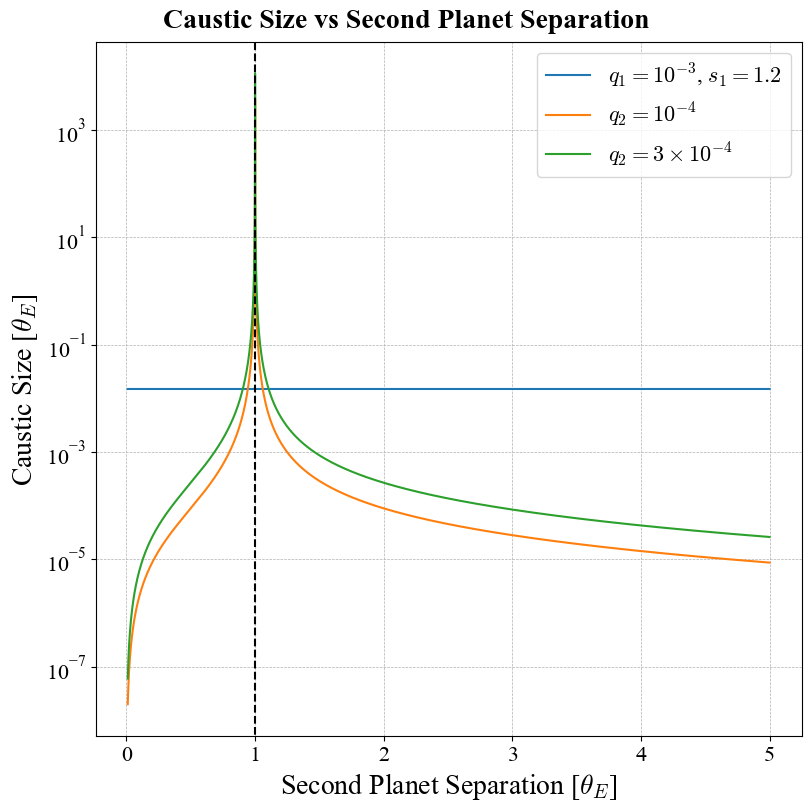

In [50]:
fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

ax.plot(s2_range, large_caustic_size * np.ones(len(s2_range)), label='$q_1 = 10^{-3}$, $s_1 = 1.2$')
ax.plot(s2_range, small_caustic_sizes_by_q2[0], label='$q_2 = 10^{-4}$')
ax.plot(s2_range, small_caustic_sizes_by_q2[1], label='$q_2 = 3 \\times 10^{-4}$')

fig.suptitle('Caustic Size vs Second Planet Separation')

# ax.set_title(f'$q_1 = {q1}$, $s_1 = {s1}$')

ax.set_xlabel('Second Planet Separation [$\\theta_E$]')
ax.set_ylabel('Caustic Size [$\\theta_E$]')

ax.set_yscale('log')

ax.legend()

ax.vlines(1, 0, 1e10, color='k', linestyle='--')

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [30]:
# Finding the s_2 values where the second planet caustic crosses over the first planet caustic size
for i in range(len(q2_range)):
    small_caustic_sizes = np.asarray(small_caustic_sizes_by_q2[i])
    diff = small_caustic_sizes - large_caustic_size

    # Indices right before a sign change (i.e. a crossover)
    crossing_idxs = np.where(np.diff(np.sign(diff)) != 0)[0]

    print(f'q2 = {q2_range[i]:.1e}:')
    for idx in crossing_idxs:
        # Linear interpolation to estimate the exact s_2 at the crossover
        s2_cross = s2_range[idx] - diff[idx] * (s2_range[idx + 1] - s2_range[idx]) / (diff[idx + 1] - diff[idx])
        direction = 'becomes LARGER' if diff[idx + 1] > diff[idx] else 'becomes smaller'
        print(f'    s2 = {s2_cross:.4f}  ({direction} than the first planet caustic)')
    print()



q2 = 1.0e-04:
    s2 = 0.9437  (becomes LARGER than the first planet caustic)
    s2 = 1.0597  (becomes smaller than the first planet caustic)

q2 = 3.0e-04:
    s2 = 0.9046  (becomes LARGER than the first planet caustic)
    s2 = 1.1054  (becomes smaller than the first planet caustic)



In [ ]:
s1 = 1.2
SS2 = ['0.2', '0.5', '0.8', '1/0.8', '1/0.5', '1/0.2']

